# Exploratory Data Analysis (EDA)

In [1]:
from pathlib import Path
from collections import Counter
import pandas as pd
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from src.util.plots.plots import get_subplot_dims, plot_image_samples
from collections import defaultdict
import hashlib

In [2]:
dataset_dir = "../data/raw"

## Dataset Overview

### Images

In [3]:
image_counts = Counter()

count = len(list(Path(dataset_dir).glob("*.ppm")))
image_counts["all_files"] = count

for file in Path(dataset_dir).iterdir():
    if file.is_dir():
        count = len(list(Path(file).glob("*.ppm")))
        image_counts[file.name] = count

In [4]:
print(f'Total images: {image_counts["all_files"]}')

print(f'Total classification images: {sum(image_counts.values()) - image_counts["all_files"]}')

Total images: 900
Total classification images: 1213


### Regions of interest (ROIs)

### The text file contains lines of the form:
#ImgNo#.ppm;#leftCol#;##topRow#;#rightCol#;#bottomRow#;#ClassID#

In [5]:
roi_description_file_path = "../data/raw/gt.txt"

df = pd.read_csv(roi_description_file_path, sep=';', header=None)

df.head()

,0,1,2,3,4,5
0,00000.ppm,774,411,815,446,11
1,00001.ppm,983,388,1024,432,40
2,00001.ppm,386,494,442,552,38
3,00001.ppm,973,335,1031,390,13
4,00002.ppm,892,476,1006,592,39


## Image Dimensions & Aspect Ratios

In [6]:
widths, heights = [], []

for img_path in Path(dataset_dir).glob("*.ppm"):
    with Image.open(img_path) as img:
        w, h = img.size
        widths.append(w)
        heights.append(h)

Width  — min: 1360, max: 1360, mean: 1360
Height — min: 800, max: 800, mean: 800


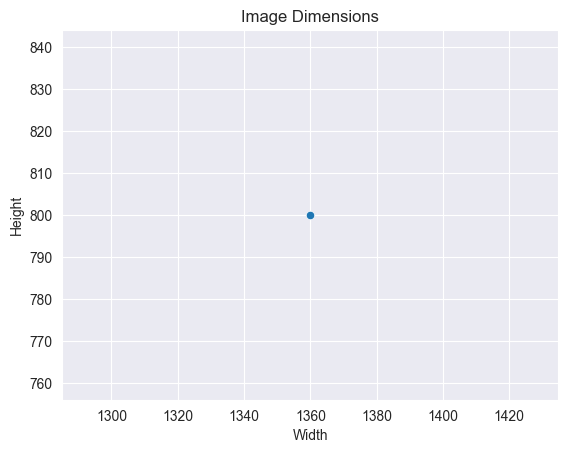

In [7]:
print(f"Width  — min: {min(widths)}, max: {max(widths)}, mean: {np.mean(widths):.0f}")
print(f"Height — min: {min(heights)}, max: {max(heights)}, mean: {np.mean(heights):.0f}")

df_wh = pd.DataFrame({
    "width": widths,
    "height": heights,
})

# plt.scatter(widths, heights, alpha=0.3)
sns.scatterplot(x="width", y="height", data=df_wh)
plt.xlabel("Width"), plt.ylabel("Height")
plt.title("Image Dimensions")
plt.show()

In [8]:
df_wh.shape

(900, 2)

## Sample Grid Visualization

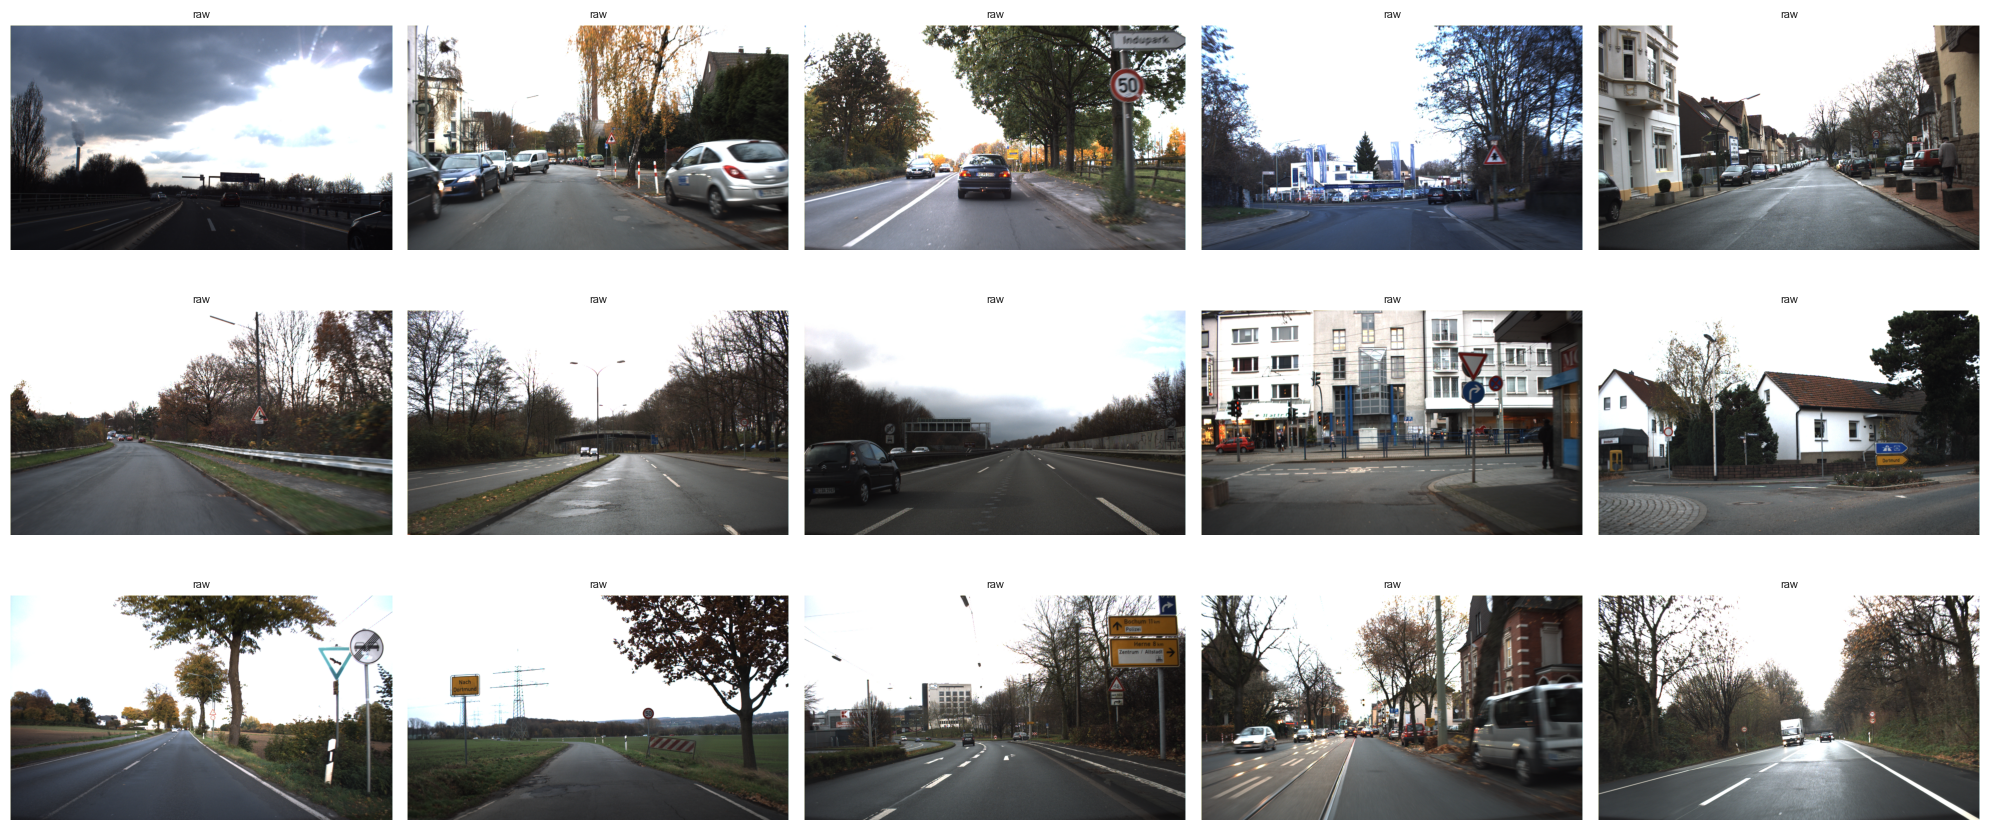

In [9]:
plot_image_samples(
    dataset_dir,
    mode="random",
    n_samples=15,
    get_subplot_dims=get_subplot_dims
)

## Corrupt or Unreadable Images

In [10]:
corrupt = []
for img_path in Path(dataset_dir).rglob("*.ppm"):
    try:
        Image.open(img_path).verify()
    except Exception:
        corrupt.append(img_path)

print(f"Corrupt images: {len(corrupt)}")

Corrupt images: 0


## Duplicate Detection

In [11]:
hashes = defaultdict(list)
for img_path in Path(dataset_dir).glob("*.ppm"):
    h = hashlib.md5(img_path.read_bytes()).hexdigest()
    hashes[h].append(img_path)

duplicates = {k: v for k, v in hashes.items() if len(v) > 1}
print(f"Duplicate groups: {len(duplicates)}")

Duplicate groups: 1


In [12]:
for h, paths in duplicates.items():
    print(f"\nHash: {h}")
    print(f"Found {len(paths)} identical files:")
    for p in paths:
        print(f"  - {p.name}")


Hash: fb11804741cbbb3598ceed2762619f47
Found 2 identical files:
  - 00613.ppm
  - 00881.ppm


Plotting 2 duplicates...


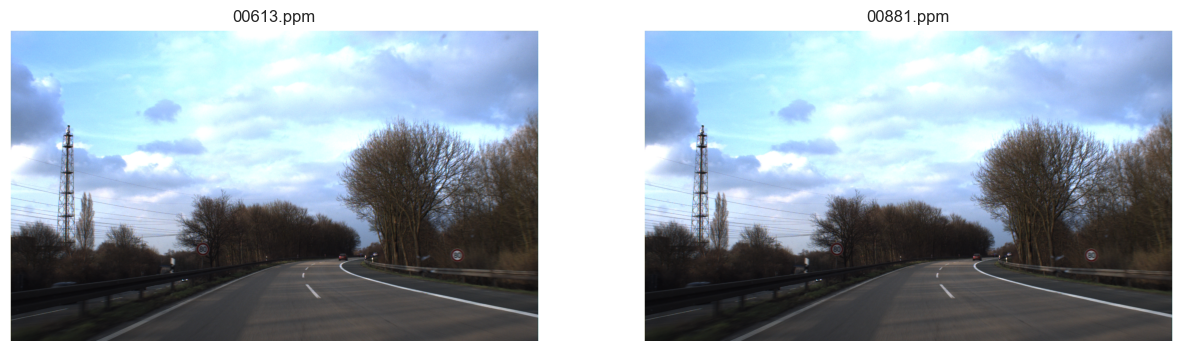

In [13]:
if duplicates:
    # Get the paths from the first duplicate group found
    first_hash = list(duplicates.keys())[0]
    duplicate_paths = duplicates[first_hash]

    print(f"Plotting {len(duplicate_paths)} duplicates...")

    # Using a simple manual plot since these are specific paths
    fig, axes = plt.subplots(1, len(duplicate_paths), figsize=(15, 5))
    if len(duplicate_paths) == 1: axes = [axes] # safety

    for ax, p in zip(axes, duplicate_paths):
        img = Image.open(p)
        ax.imshow(img)
        ax.set_title(p.name)
        ax.axis('off')
    plt.show()

## Key Metrics Summary

In [14]:
# image sizes
min_widths = min(widths)
max_widths = max(widths)
mean_widths = np.mean(widths)
median_widths = np.median(widths)
min_heights = min(heights)
max_heights = max(heights)
mean_heights = np.mean(heights)
median_heights = np.median(heights)

# corrupted files
num_corrupt = len(corrupt)

# duplicate files
num_duplicates = len(duplicates)

# aspect ratios
aspect_ratios = [w/h for w, h in zip(widths, heights)]

min_aspect_ratio = min(aspect_ratios)
max_aspect_ratio = max(aspect_ratios)
average_aspect_ratio = np.mean(aspect_ratios)
median_aspect_ratio = np.median(aspect_ratios)

In [15]:
metrics = {
    "Image width": [min_widths, max_widths, mean_widths, median_widths, ""],
    "Image height": [min_heights, max_heights, mean_heights, median_heights, ""],
    "Aspect ratio": [min_aspect_ratio, max_aspect_ratio, average_aspect_ratio, median_aspect_ratio, ""],
    "Corrupted files": [num_corrupt, "", "", "", ""],
    "Duplicate files": [num_duplicates, "", "", "", ""],

}

index = ["Min", "Max", "Mean", "Median", "Imbalance/Count"]

df = pd.DataFrame(metrics, index=index)
display(df)

,Image width,Image height,Aspect ratio,Corrupted files,Duplicate files
Min,1360,800,1.7,0,1
Max,1360,800,1.7,,
Mean,1360.0,800.0,1.7,,
Median,1360.0,800.0,1.7,,
Imbalance/Count,,,,,
